In [ ]:
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('USMA1Q-Methodes-Numeriques'):
        !git clone https://github.com/nickcollins-craft/USMA1Q-Methodes-Numeriques.git
        os.chdir('USMA1Q-Methodes-Numeriques/seance_7')
    else:
        os.chdir('USMA1Q-Methodes-Numeriques')
        !git pull
        os.chdir('seance_7')

# USMA1Q — Méthodes Numériques
## Exercices Séance 7 — Systèmes d'équations non linéaires
### Solutions

## Exercice 1 — Tangente commune avec Jacobien analytique

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def G_alpha(x):
    return 17.0 * (x - 0.4)**2 + 0.4

def G_beta(x):
    return 5.0 * (x - 0.9)**2 + 0.2

def dG_alpha(x):
    return 34.0 * (x - 0.4)

def dG_beta(x):
    return 10.0 * (x - 0.9)

# 1. Résiduelle F(x)
def F(x):
    x1, x2 = x[0], x[1]
    dx = x2 - x1
    dG = G_beta(x2) - G_alpha(x1)
    F1 = dG_alpha(x1) - dG_beta(x2)
    F2 = dG_alpha(x1) - dG / dx
    return np.array([F1, F2])

In [ ]:
# 2. Jacobien analytique
def J(x):
    x1, x2 = x[0], x[1]
    dx = x2 - x1
    dG = G_beta(x2) - G_alpha(x1)
    J00 = 34.0
    J01 = -10.0
    J10 = 34.0 + dG_alpha(x1)/dx - dG/dx**2
    J11 = -dG_beta(x2)/dx + dG/dx**2
    return np.array([[J00, J01], [J10, J11]])

In [22]:
# 3. Newton–Raphson
x = np.array([0.3, 0.7])

print("Iter |   x1          x2        |     ||F||")
for k in range(20):
    Fk = F(x)
    print("%4d | %.10f  %.10f | %.2e" % (k, x[0], x[1], np.linalg.norm(Fk)))
    if np.linalg.norm(Fk) < 1e-10:
        break
    dx_step = np.linalg.solve(J(x), -Fk)
    x = x + dx_step

print()
print("Solution : x1 =", round(x[0], 8), " x2 =", round(x[1], 8))

Iter |   x1          x2        |     ||F||
   0 | 0.3000000000  0.7000000000 | 3.29e+00
   1 | 0.3882665832  0.8601063830 | 1.30e-02
   2 | 0.3878825429  0.8588006458 | 1.27e-05
   3 | 0.3878829173  0.8588019187 | 1.21e-11

Solution : x1 = 0.38788292  x2 = 0.85880192


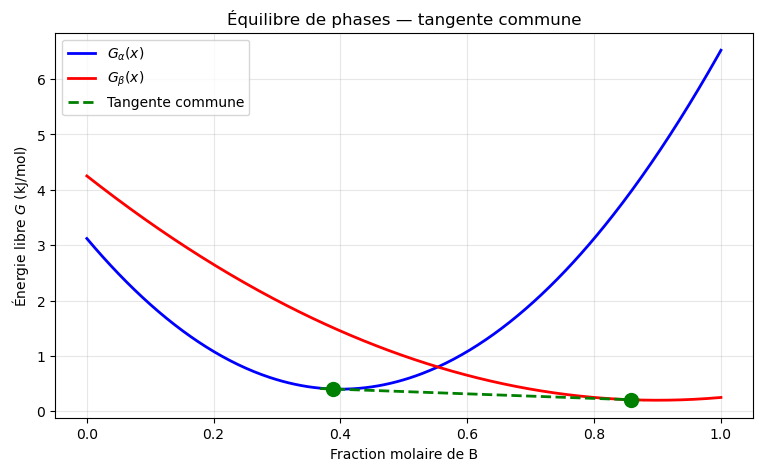

In [5]:
# 4. Tracé
x_range = np.linspace(0.0, 1.0, 400)

plt.figure(figsize=(9, 5))
plt.plot(x_range, G_alpha(x_range), 'b-', lw=2, label=r'$G_\alpha(x)$')
plt.plot(x_range, G_beta(x_range),  'r-', lw=2, label=r'$G_\beta(x)$')

x1_sol, x2_sol = x[0], x[1]
pente = dG_alpha(x1_sol)
x_tang = np.array([x1_sol - 0.02, x2_sol + 0.02])
y_tang = G_alpha(x1_sol) + pente * (x_tang - x1_sol)
plt.plot(x_tang, y_tang, 'g--', lw=2, label='Tangente commune')
plt.plot([x1_sol, x2_sol], [G_alpha(x1_sol), G_beta(x2_sol)], 'go', ms=10)

plt.xlabel('Fraction molaire de B')
plt.ylabel('Énergie libre $G$ (kJ/mol)')
plt.title('Équilibre de phases — tangente commune')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Partie 2 — Jacobien numérique et recherche linéaire

### Exercice 2.1 — Jacobien numérique

In [6]:
# Les fonctions G_alpha, G_beta, dG_alpha, dG_beta, F et J sont définies à l'exercice 1

def jacobien_numerique(F, x, delta=1e-8):
    n = len(x)
    F0 = F(x)
    J_num = np.zeros((n, n))
    for j in range(n):
        x_pert = x.copy()
        x_pert[j] += delta
        J_num[:, j] = (F(x_pert) - F0) / delta
    return J_num

x_test = np.array([0.3, 0.7])
print("Jacobien analytique :")
print(J(x_test))
print("Jacobien numérique :")
print(jacobien_numerique(F, x_test))
print("Différence max :", np.max(np.abs(J(x_test) - jacobien_numerique(F, x_test))))

Jacobien analytique :
[[ 34.     -10.    ]
 [ 26.5625   3.9375]]
Jacobien numérique :
[[ 33.99999997 -10.00000007]
 [ 26.5625002    3.93749979]]
Différence max : 2.0711684323160284e-07


### Exercice 2.2 — Recherche linéaire (backtracking line search)

In [7]:
def F_func(x):
    x1, x2 = x[0], x[1]
    return np.array([x1**2 - x2, x2**2 - x1])

def J_func(x):
    x1, x2 = x[0], x[1]
    return np.array([[2.0 * x1, -1.0], [-1.0, 2.0 * x2]])

def newton_avec_recherche_lineaire(F, J_func, x0, tol=1e-10, max_iter=50):
    x = x0.copy()
    norms = [np.linalg.norm(F(x))]
    for k in range(max_iter):
        Fk = F(x)
        if np.linalg.norm(Fk) < tol:
            break
        dx_step = np.linalg.solve(J_func(x), -Fk)
        alpha = 1.0
        norme0 = np.linalg.norm(Fk)
        while np.linalg.norm(F(x + alpha * dx_step)) >= norme0:
            alpha *= 0.5
            if alpha < 1e-14:
                break
        x = x + alpha * dx_step
        norms.append(np.linalg.norm(F(x)))
    return x, norms

In [8]:
# 2. Résoudre depuis x0 = [0.49, 0.51]
x0 = np.array([0.49, 0.51])
x_sol, norms = newton_avec_recherche_lineaire(F_func, J_func, x0)
print("Solution :", x_sol)
print("||F(x*)||:", np.linalg.norm(F_func(x_sol)))

Solution : [-1.89787312e-15 -1.62679957e-18]
||F(x*)||: 1.8978738136063683e-15


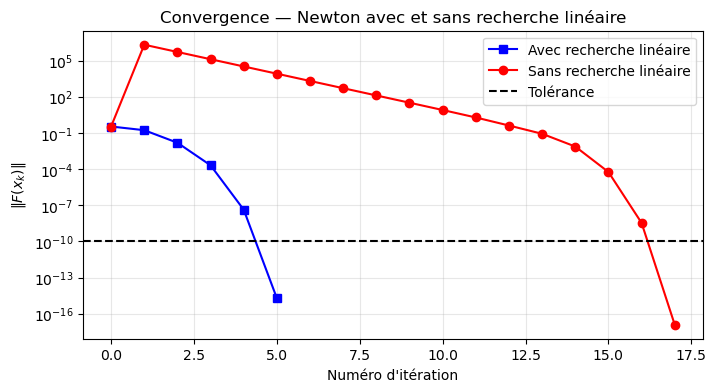

In [23]:
# 3. Solveur Newton sans recherche linéaire pour comparaison
def newton_sans_recherche_lineaire(F, J_func, x0, tol=1e-10, max_iter=50):
    x = x0.copy()
    norms = [np.linalg.norm(F(x))]
    for k in range(max_iter):
        Fk = F(x)
        if np.linalg.norm(Fk) < tol:
            break
        try:
            dx_step = np.linalg.solve(J_func(x), -Fk)
        except np.linalg.LinAlgError:
            break
        x = x + dx_step
        norms.append(np.linalg.norm(F(x)))
    return x, norms

x0 = np.array([0.49, 0.51])
_, norms_avec = newton_avec_recherche_lineaire(F_func, J_func, x0)
_, norms_sans = newton_sans_recherche_lineaire(F_func, J_func, x0)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(range(len(norms_avec)), norms_avec, 'b-s', ms=6, label='Avec recherche linéaire')
plt.semilogy(range(len(norms_sans)), norms_sans, 'r-o', ms=6, label='Sans recherche linéaire')
plt.axhline(1e-10, color='k', ls='--', label='Tolérance')
plt.xlabel("Numéro d'itération")
plt.ylabel(r'$\|F(x_k)\|$')
plt.title('Convergence — Newton avec et sans recherche linéaire')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.show()

## Exercice 3 — Loi de plasticité de von Mises avec `scipy.optimize.root`

In [10]:
import numpy as np
from scipy.optimize import root

E         = 200000.0
sigma_y   = 250.0
sigma_inf = 500.0
b         = 20.0
eps_p_n   = 0.0
eps_n1    = 0.005

sigma_trial = E * (eps_n1 - eps_p_n)
print("Contrainte d'essai :", sigma_trial, "MPa")
print("Seuil actuel       :", sigma_y, "MPa")
print("Plastification ?   :", sigma_trial > sigma_y)

Contrainte d'essai : 1000.0 MPa
Seuil actuel       : 250.0 MPa
Plastification ?   : True


In [11]:
def F_plasticite(x):
    sigma, eps_p = x[0], x[1]
    F1 = sigma - E * (eps_n1 - eps_p)
    F2 = sigma - sigma_y - (sigma_inf - sigma_y) * (1.0 - np.exp(-b * eps_p))
    return np.array([F1, F2])

x_essai = np.array([sigma_trial, eps_p_n])
print("F au point d'essai :", F_plasticite(x_essai))

F au point d'essai : [  0. 750.]


In [12]:
sol = root(F_plasticite, x0=[sigma_trial, eps_p_n], method='hybr')

sigma_sol = sol.x[0]
eps_p_sol = sol.x[1]

print("Convergé       :", sol.success)
print("||F(x*)||      :", np.linalg.norm(sol.fun))
print("sigma_n+1      :", round(sigma_sol, 3), "MPa")
print("eps_p,n+1      :", round(eps_p_sol, 6))
print("sigma_seuil    :", round(sigma_y + (sigma_inf - sigma_y)*(1 - np.exp(-b*eps_p_sol)), 3), "MPa")

Convergé       : True
||F(x*)||      : 3.552713678800501e-14
sigma_n+1      : 267.654 MPa
eps_p,n+1      : 0.003662
sigma_seuil    : 267.654 MPa


sigma_y/E = 0.00125


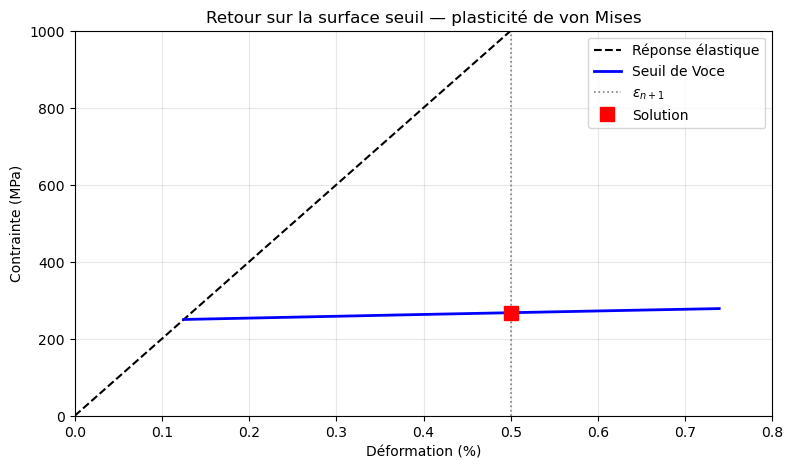

In [ ]:
import matplotlib.pyplot as plt

eps_range      = np.linspace(0, 0.012, 300)
sigma_elastic  = E * eps_range
eps_p_range    = np.linspace(0, 0.006, 300)
sigma_voce     = sigma_y + (sigma_inf - sigma_y) * (1 - np.exp(-b * eps_p_range))
eps_total_voce = eps_p_range + sigma_voce / E

plt.figure(figsize=(9, 5))
plt.plot(eps_range * 100, sigma_elastic, 'k--', lw=1.5, label='Réponse élastique')
plt.plot(eps_total_voce * 100, sigma_voce, 'b-', lw=2, label='Seuil de Voce')
plt.axvline(eps_n1 * 100, color='gray', ls=':', lw=1.2, label=r'$\varepsilon_{n+1}$')
plt.plot(eps_n1 * 100, sigma_sol, 'rs', ms=10, zorder=5, label='Solution')
plt.xlabel('Déformation (%)')
plt.ylabel('Contrainte (MPa)')
plt.title('Retour sur la surface seuil — plasticité de von Mises')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 0.8)
plt.ylim(0, 1000)
plt.show()